In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ssmask.rf_model import *

In [94]:
Band = rf.Frequency(2.05e11, 2.95e11, 10001, 'hz')
fres_out = np.array([2.2, 2.8])*1e11
fres_in = np.linspace(2.3, 2.7, 16)*1e11
fres = np.append(fres_out[0], np.append(fres_in, fres_out[-1]))
N_res = len(fres)

Qc = 600
Qloss = 1e4
Pdet_out = 0.3
Qc_out = 5000 #Qloss*((2/Pdet_out)**.5 - 2)

Qc1_arr = np.full(N_res, Qc)
Qc2_arr = np.full(N_res, Qc)
Qc1_arr[[0,-1]] = Qc_out
Qc2_arr[[0,-1]] = Qc_out
Qloss_arr = np.full(N_res, Qloss)
Z0 = 32
physSep = 0.75
epsr = 8.3
Ntwk = FilterBankLossy(Band, fres, Qc1_arr, Qc2_arr, Qloss_arr, Z0, physSep, epsr, lossTan=1/Qloss)

[Text(0.5, 0, 'mm-wave freq [GHz]'),
 Text(0, 0.5, 'Filtered power'),
 None,
 (0.01, 1)]

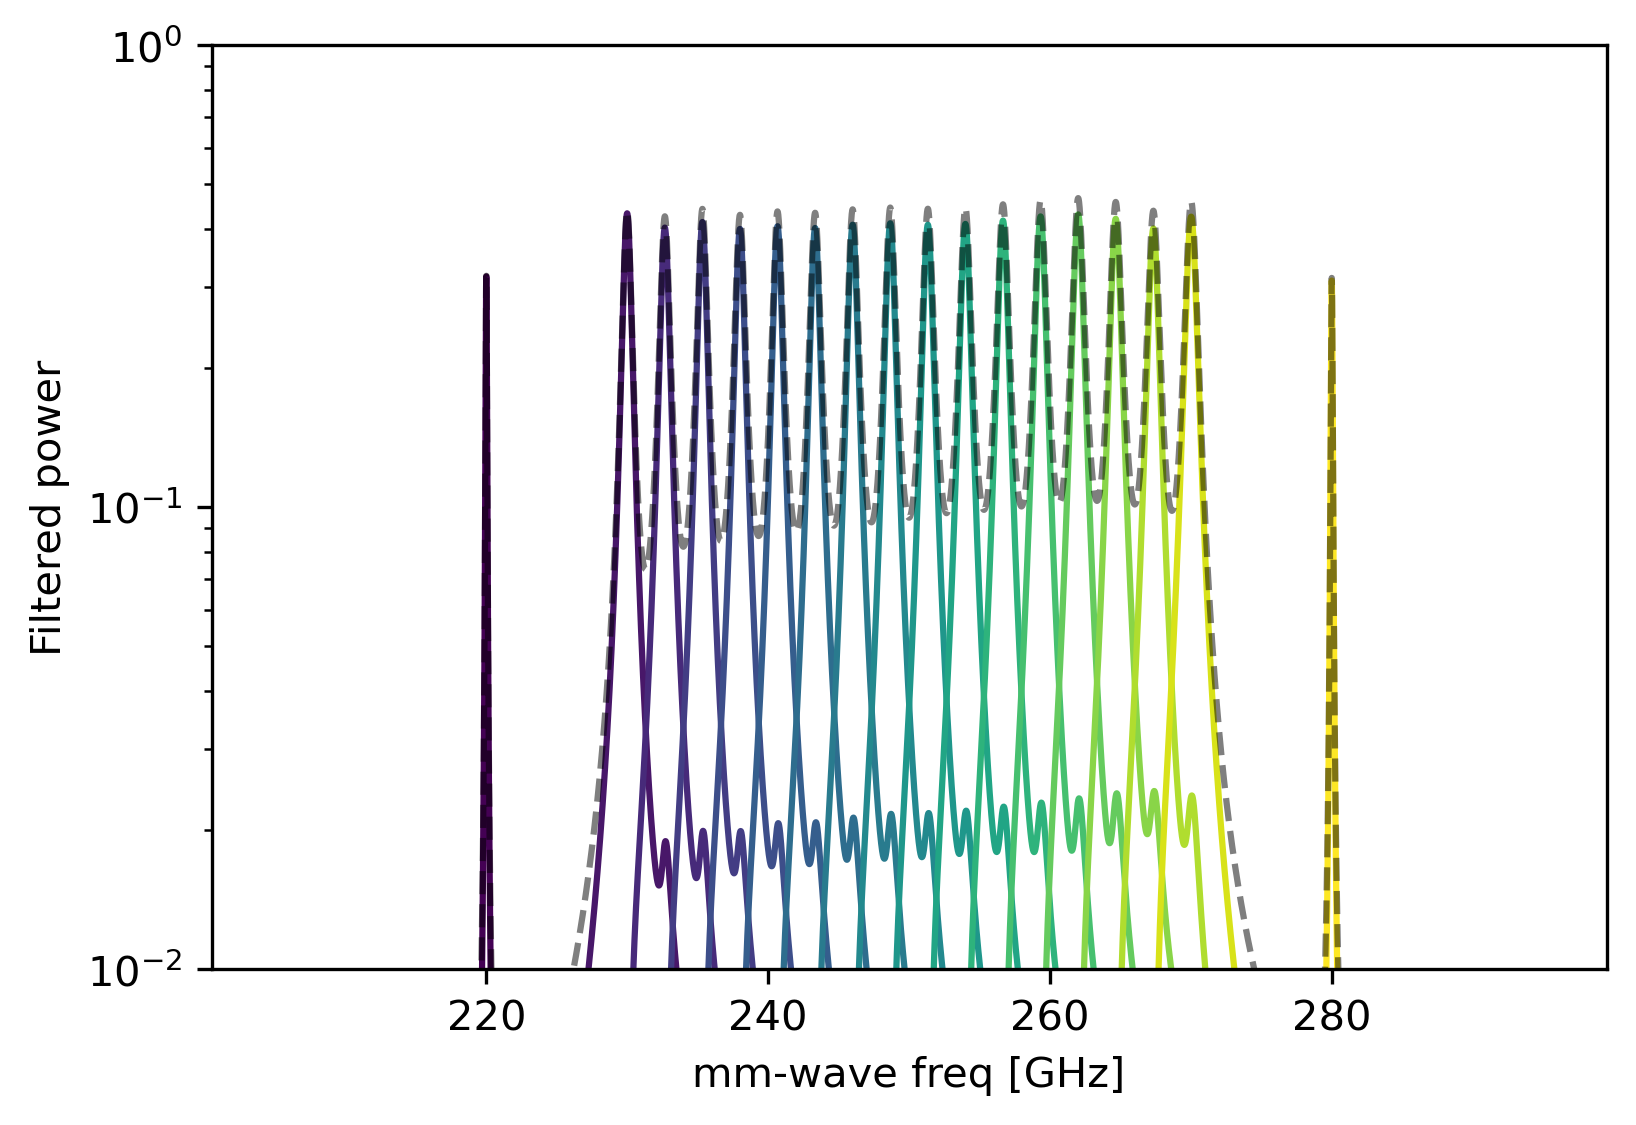

In [95]:
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=N_res-1)
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])
fig, ax = plt.subplots(figsize=(6,4), dpi=300)
Ptot = np.zeros(len(Band))

for ii in range(N_res):
    Pchan = np.abs(Ntwk.s[:,1+ii,0])**2
    Ptot += Pchan
    ax.plot(Band.f/1.0e9, np.abs(Ntwk.s[:,1+ii,0])**2, c=cmap.to_rgba(ii))
    
ax.plot(Band.f/1.0e9, Ptot, 'k--', alpha=0.5)
ax.set(xlabel='mm-wave freq [GHz]', ylabel='Filtered power', yscale='log', ylim=[1e-2,1])
# ax.legend(loc='upper right', title='Qloss')

In [96]:
Qc_out

5000

In [97]:
max(Ptot)

0.4665714676286025

In [98]:
Ptot[np.argmin(abs(Band.f-fres[0]))]

0.3167993931168181

In [93]:
fres

array([2.20000000e+11, 2.30000000e+11, 2.32666667e+11, 2.35333333e+11,
       2.38000000e+11, 2.40666667e+11, 2.43333333e+11, 2.46000000e+11,
       2.48666667e+11, 2.51333333e+11, 2.54000000e+11, 2.56666667e+11,
       2.59333333e+11, 2.62000000e+11, 2.64666667e+11, 2.67333333e+11,
       2.70000000e+11, 2.80000000e+11])